In [1]:
import sys, os
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110

In [2]:
import plotting as pl
import tools.evaluation as ev
from tools.dataset import load_well
from tools.spatial import PYRAMID_SCALES
from models import recipe
from models.graph import border_mask
from tools.spatial import add_mask_pyramid, add_intensity_pyramid
from tools.morphology import indices_to_mask

In [3]:
PRIMARY_WELL = 'W8_pattern1_Sox17_Brachyury'
RESULTS = '/Users/allywang/Desktop/work/F2026/OptoBMP/results/figures'
IF_BACKGROUNDS = {
    "Sox17_mean": 349.27417498634907,
    "T_mean": 384.42064880441285,
}
FIG_DIR = f'{RESULTS}/{PRIMARY_WELL}'

EPOCHS = 2500
PATIENCE = 400 
# EPOCHS = 10
# PATIENCE = 50

In [4]:
df = load_well(PRIMARY_WELL)
df.head(3)

,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+,BMP4_bin
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.058548,629.522248,427.0,85.941125,84.158813,0.603269,0.908511,0.640180,27.763694,22.142602,...,1.253859,264.735363,124.067916,347.723653,1366.845433,False,False,False,True,0.0
2,9.803440,4872.491400,407.0,76.526912,75.233579,0.618904,0.946512,0.740000,26.030466,20.446056,...,1.273129,216.383292,118.837838,198.417690,758.594595,False,False,False,True,0.0
3,9.231250,7124.062500,160.0,54.970563,54.796878,0.911222,0.879121,0.661157,22.911059,9.437440,...,2.427677,226.725000,136.756250,379.668750,1362.175000,False,False,False,True,0.0


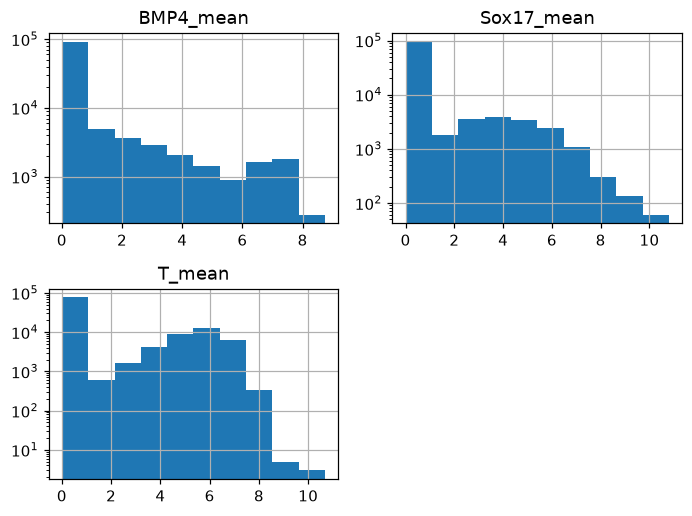

In [5]:
BACKGROUNDS = recipe.normalize(df, ['BMP4_mean', 'Sox17_mean', 'T_mean'], backgrounds=IF_BACKGROUNDS)
df[['BMP4_mean', 'Sox17_mean', 'T_mean']].hist(log=True)
plt.tight_layout()

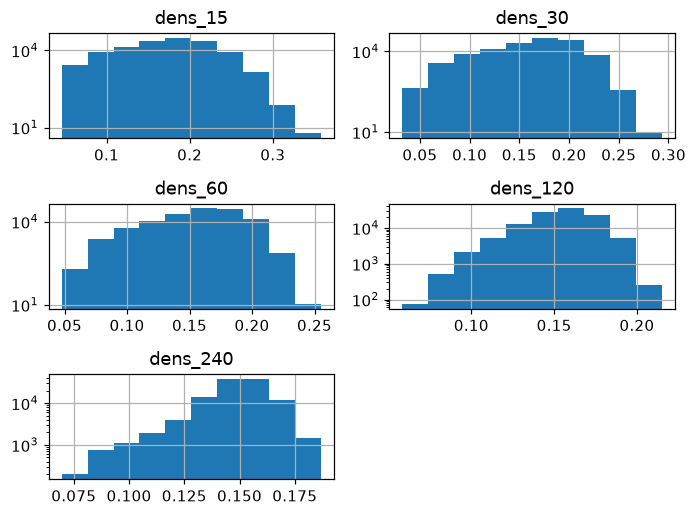

In [6]:
X_DENSITY = recipe.density_features(df, max_sigma=recipe.MAX_SIGMA)

_ = df[X_DENSITY ].hist(log=True)
plt.tight_layout()

In [7]:
# The edge cells are going to be less dense, so we should remove them 

print(df.shape)
df = df[(
    (df['centroid_y'] > recipe.MAX_SIGMA) & (df['centroid_y'] < df['centroid_y'].max() - recipe.MAX_SIGMA) & 
    (df['centroid_x'] > recipe.MAX_SIGMA) & (df['centroid_x'] < df['centroid_x'].max() - recipe.MAX_SIGMA)
)]
centroids = df[['centroid_y', 'centroid_x']].to_numpy(np.float32)
print(df.shape)


(111511, 34)
(96316, 34)


In [8]:
shape = (int(centroids[:,0].max())+2, int(centroids[:,1].max())+2)
valid = np.where(~border_mask(centroids, shape, recipe.RADIUS))[0]

SPLITS = {
    'random':  tuple(valid[i] for i in ev.random_split(len(valid), seed=0)),
    'blocked': tuple(valid[i] for i in ev.spatial_block_split(centroids[valid], block=800.0, seed=0)),
}
N = len(df)
MASKS = {k: tuple(indices_to_mask(i, N) for i in v) for k, v in SPLITS.items()}
for k, (tr, va, te) in SPLITS.items():
    print(f'{k:8s} train/val/test = {len(tr):,}/{len(va):,}/{len(te):,}')

random   train/val/test = 66,843/14,323/14,323
blocked  train/val/test = 67,184/15,309/12,996


### Predict from densities alone

In [9]:
fname = 'densities'
cols = X_DENSITY
os.makedirs(FIG_DIR, exist_ok=True)

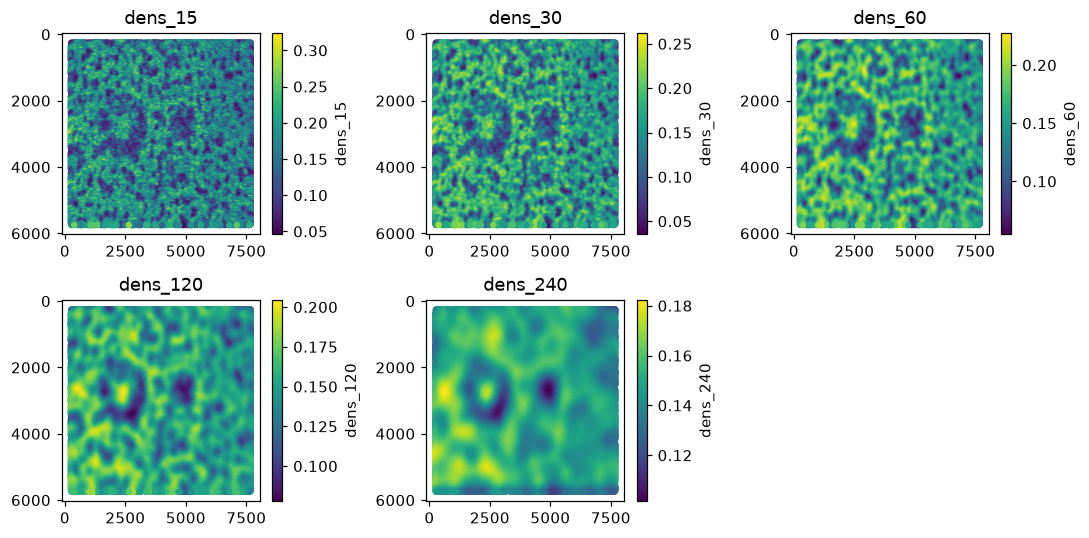

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs = axs.flatten()

for ax, col in zip(axs, cols):
    sc = ax.scatter(
        df['centroid_x'],
        df['centroid_y'],
        c=df[col],
        s=10,
        alpha=1,
        cmap='viridis'
    )
    ax.invert_yaxis()
    ax.set_title(col)
    fig.colorbar(sc, ax=ax, label=col)

for ax in axs[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/X_{fname}.png')

In [11]:
rows, fitted = [], {}
for marker in ['Sox17', 'T']:

    y_col = f'{marker}_mean'
    
    for split_name, (tr, va, te) in SPLITS.items():
        trm, vam, tem = MASKS[split_name]

        model, data, log_w, history = recipe.fit(
            df, cols, y_col, trm, vam, tr, 
            epochs=EPOCHS, patience=PATIENCE, verbose=False)

        pred = recipe.predict(model, data, log_w)
        y = data['y'].numpy().ravel(); ypos = data['y_positive'].numpy().ravel()
        t = tem.numpy()
        met = ev.evaluate(y[t], pred[t], ypos[t])
        rows.append(dict(target=marker, split=split_name, features=fname, **met))
        fitted[(marker, split_name)] = dict(model=model, data=data, log_w=log_w, history=history,
                                                    pred=pred, y=y, ypos=ypos, metrics=met)
        print(f'{marker:6s} {split_name:8s} {fname:24s} '
                f'R2={met["r2"]:+.4f}  AUROC={met.get("auroc", float("nan")):.3f}')

results = pd.DataFrame(rows)
results.to_csv(f'{FIG_DIR}/models_{fname}.csv')
results.round(4)

Sox17  random   densities                R2=+0.1030  AUROC=0.713
Sox17  blocked  densities                R2=+0.0143  AUROC=0.617
T      random   densities                R2=+0.2699  AUROC=0.810
T      blocked  densities                R2=+0.1692  AUROC=0.764


,target,split,features,r2,pearson,spearman,auroc,ap,base_rate,r2_positives
0,Sox17,random,densities,0.1030,0.3211,0.2655,0.7133,0.3298,0.1489,-3.0944
1,Sox17,blocked,densities,0.0143,0.1205,0.1455,0.6175,0.2123,0.1573,-3.4949
2,T,random,densities,0.2699,0.5197,0.5088,0.8103,0.6423,0.3119,-4.7283
3,T,blocked,densities,0.1692,0.4226,0.4232,0.7635,0.5433,0.3028,-4.8964


===== Sox17 random =====


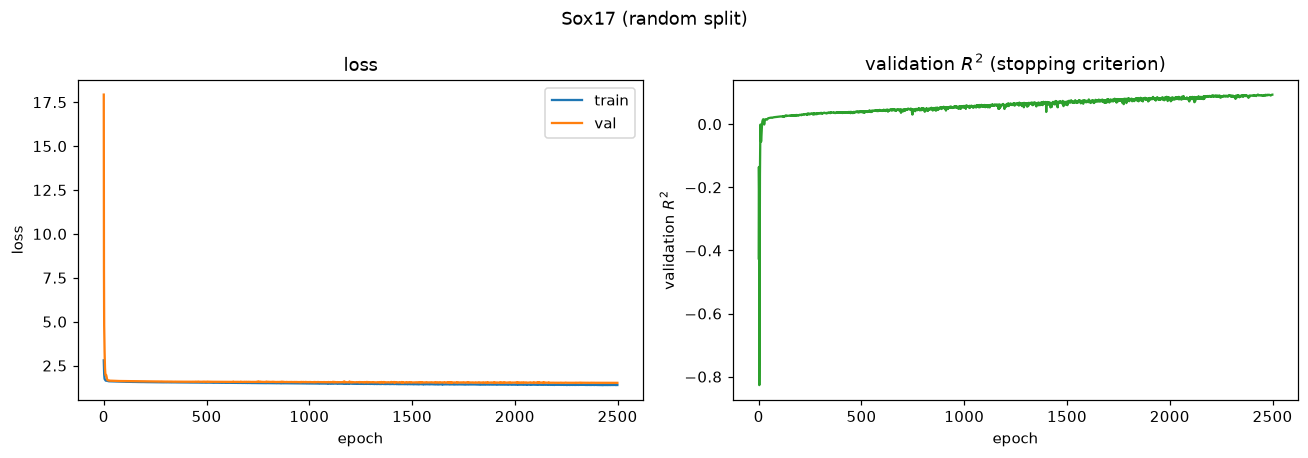

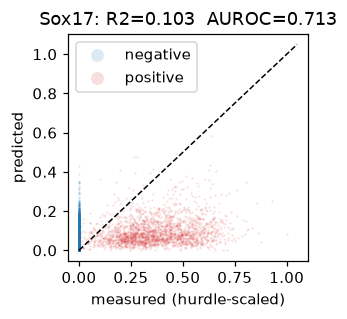

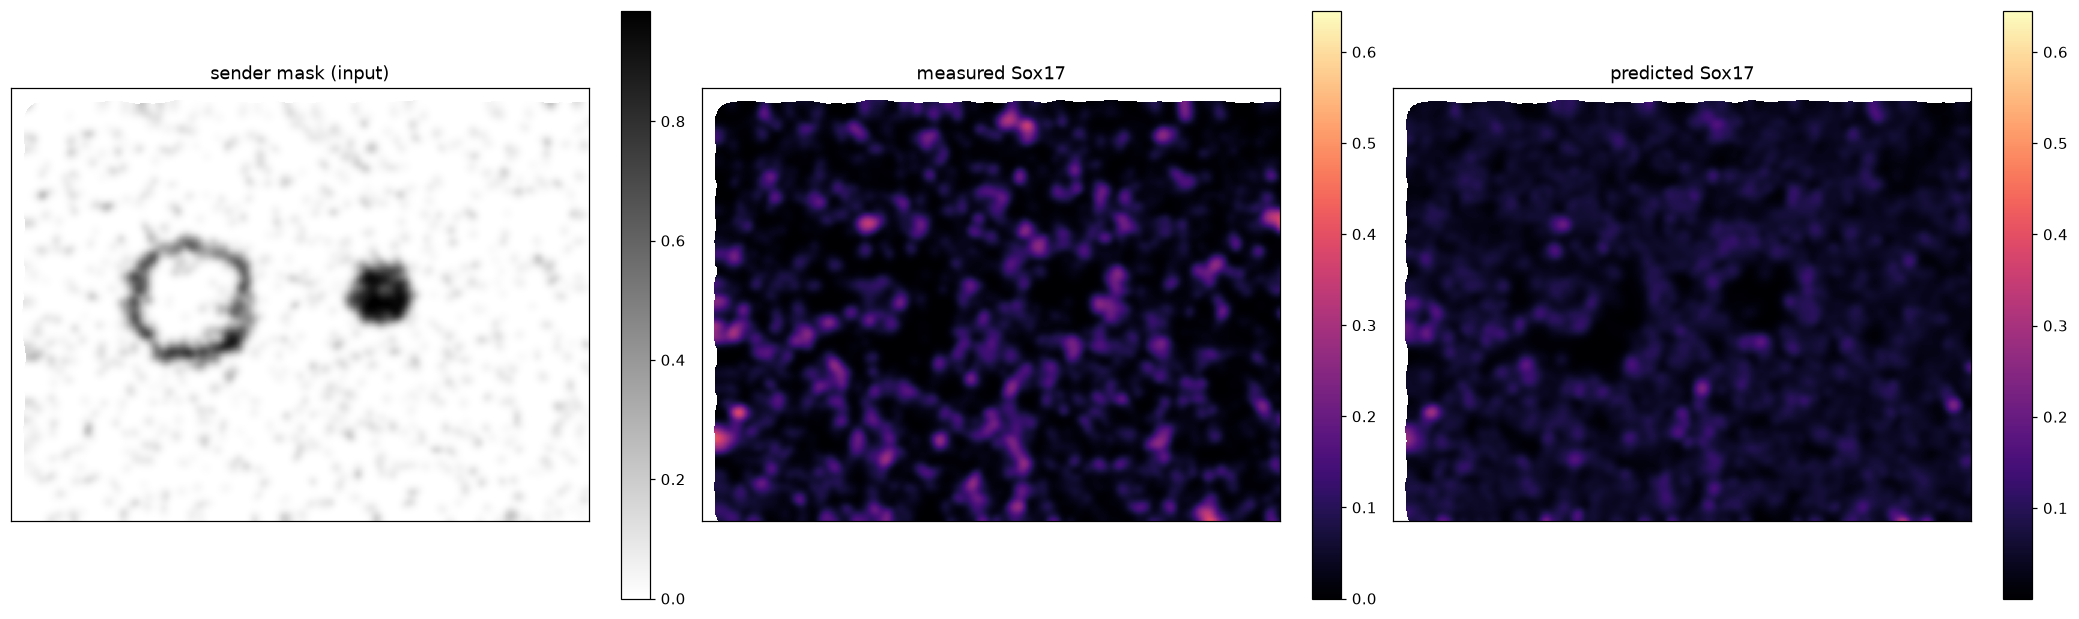

===== Sox17 blocked =====


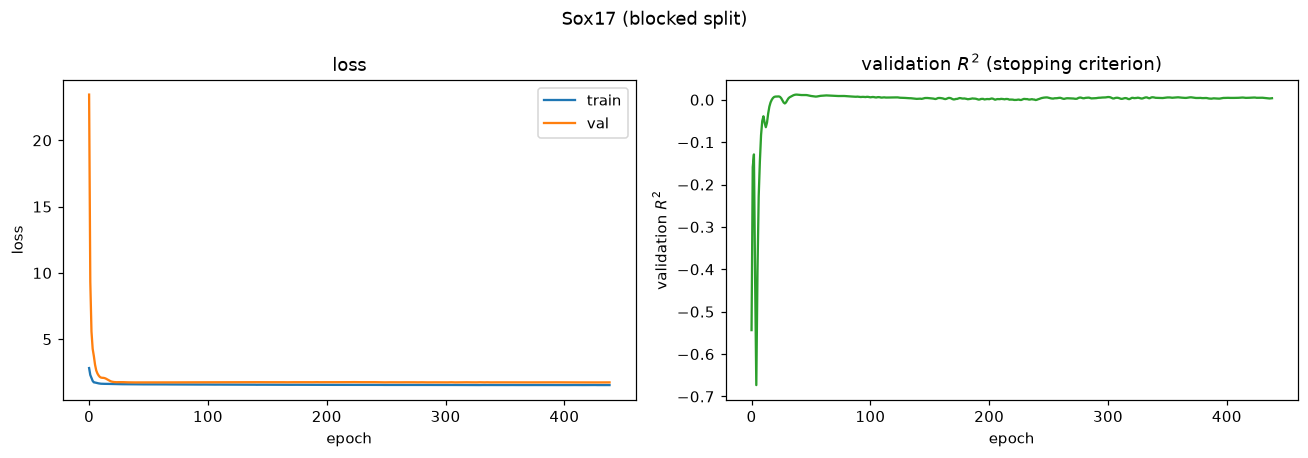

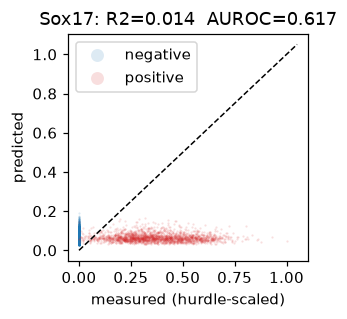

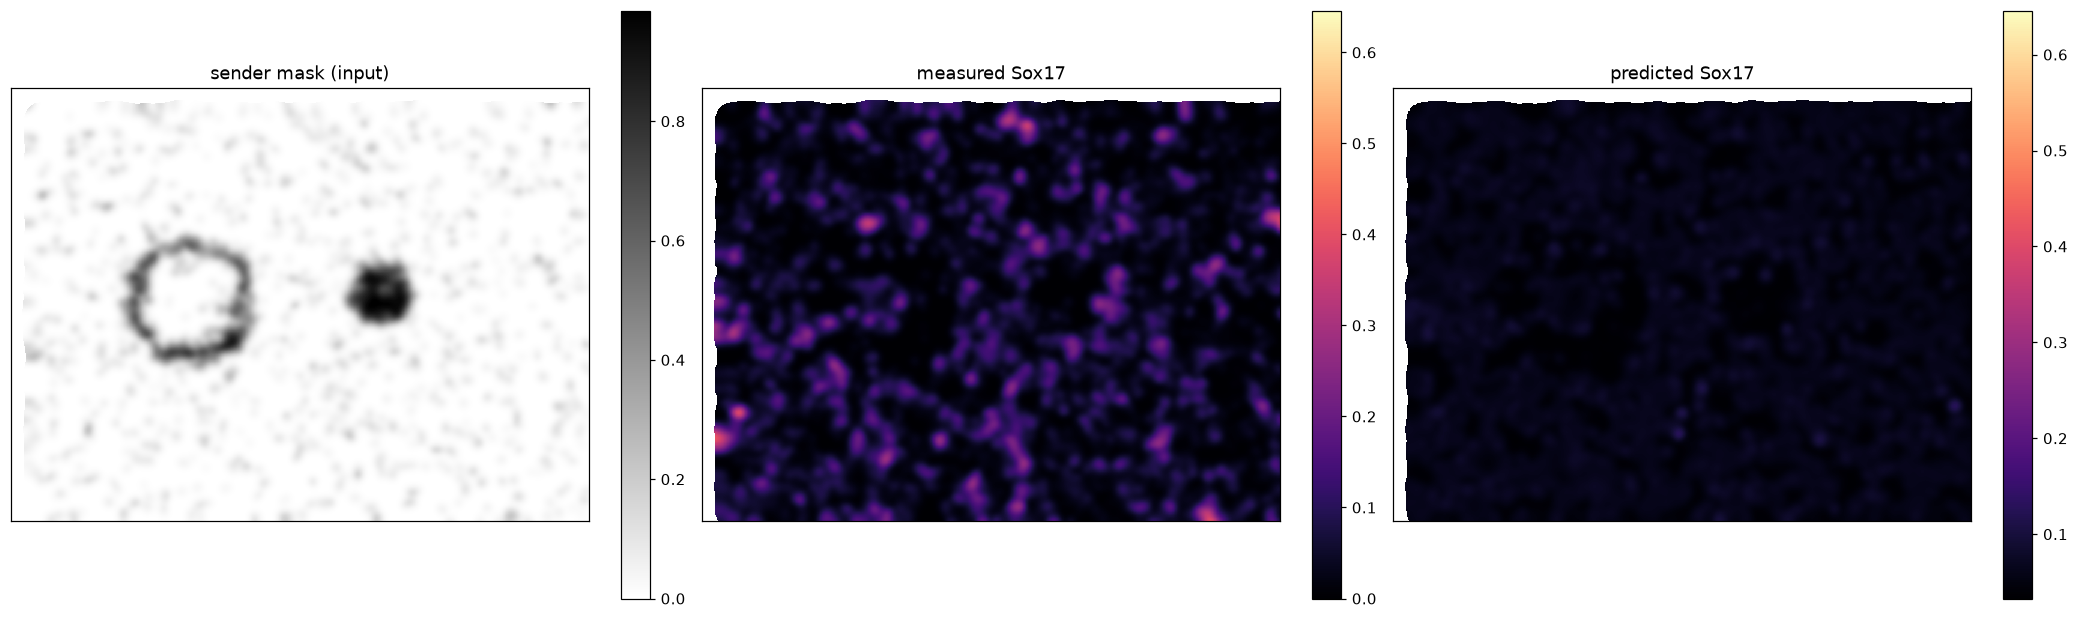

===== T random =====


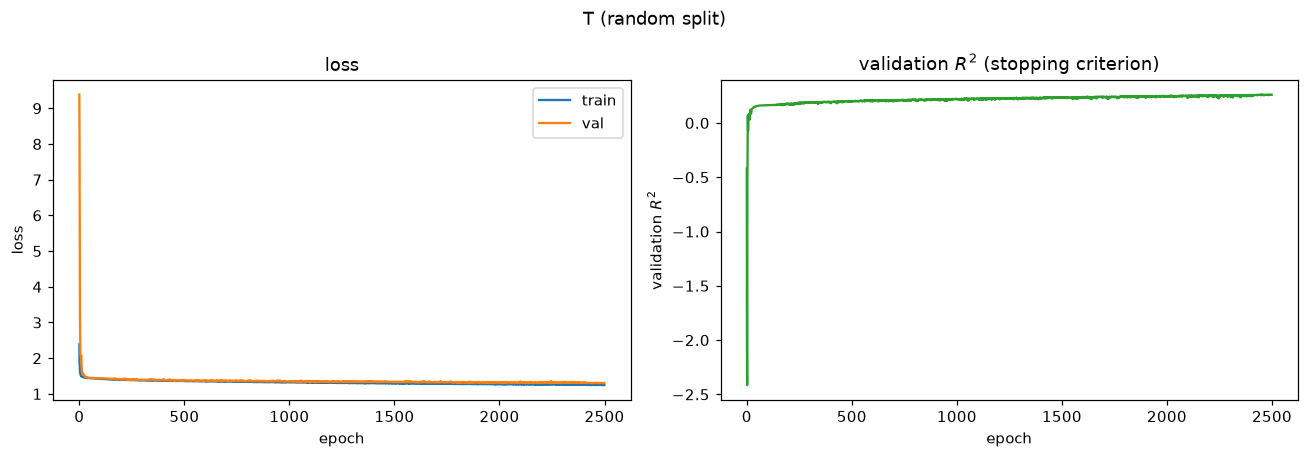

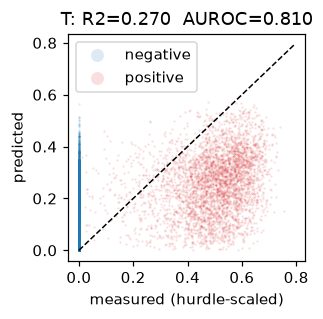

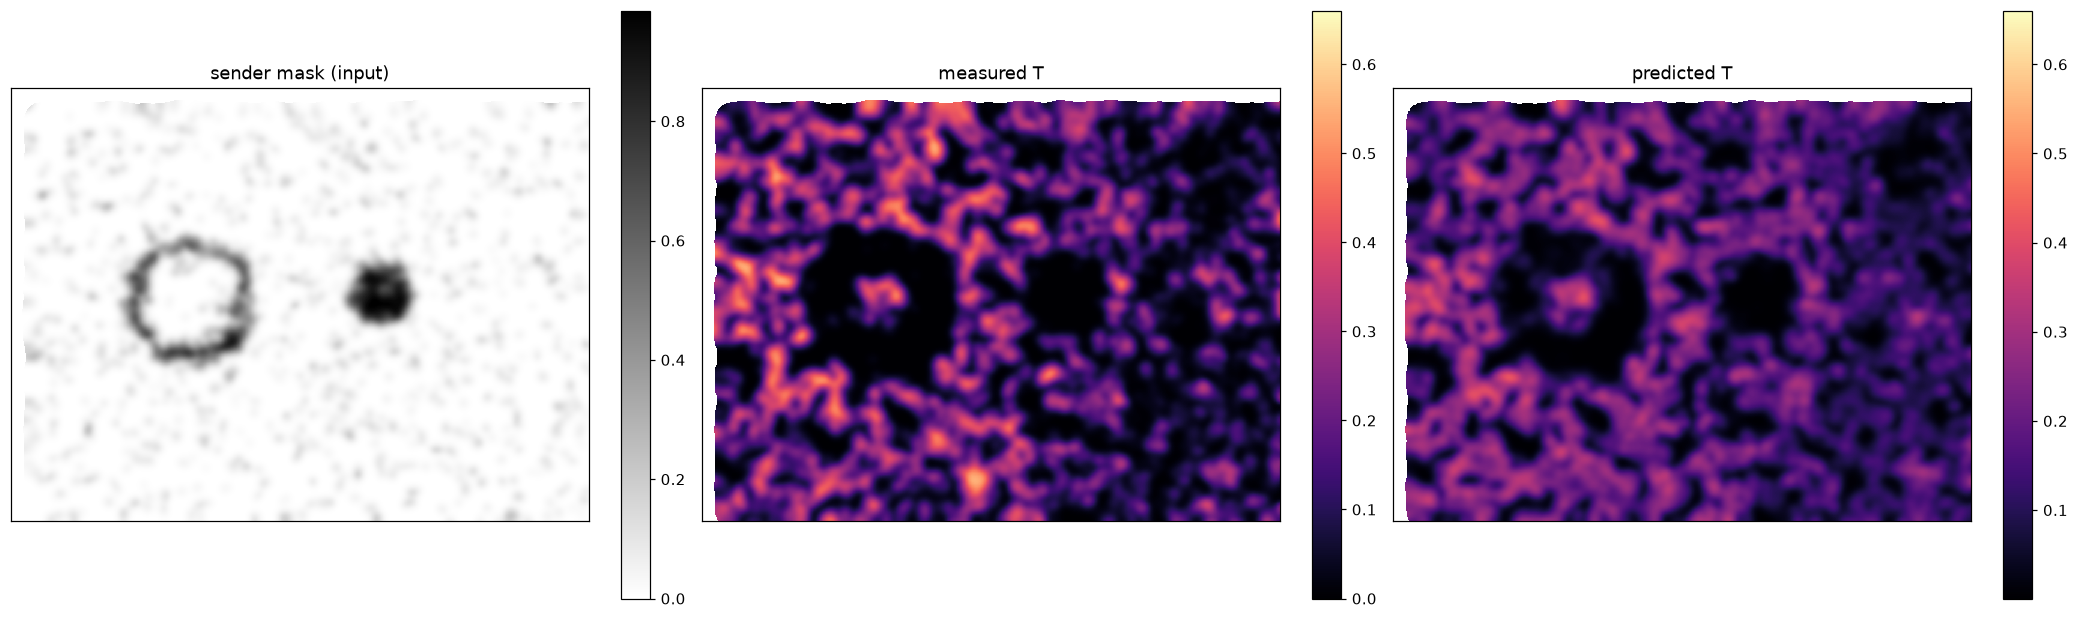

===== T blocked =====


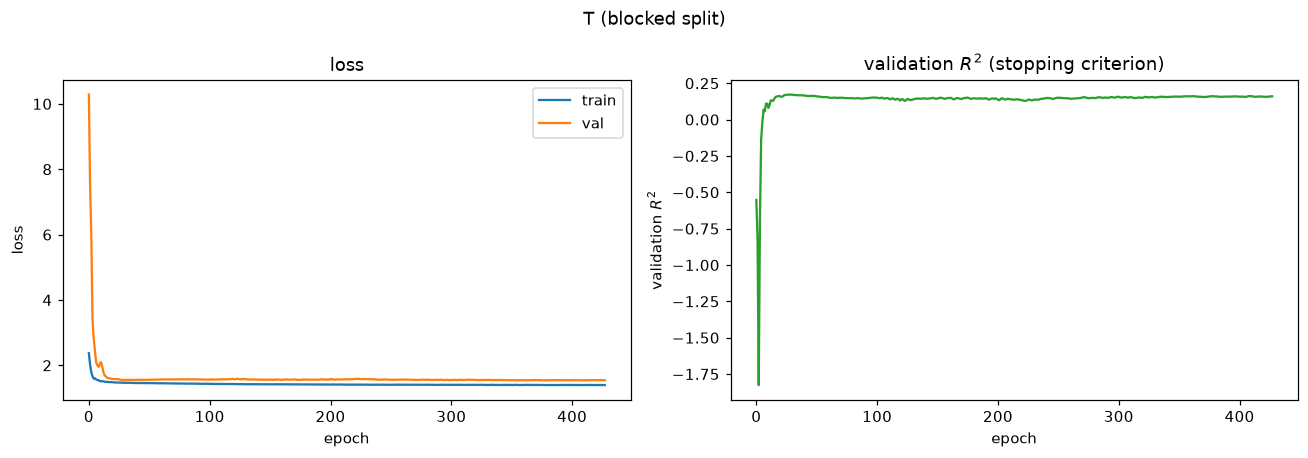

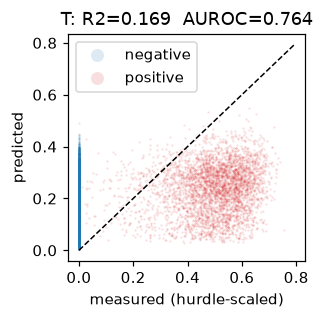

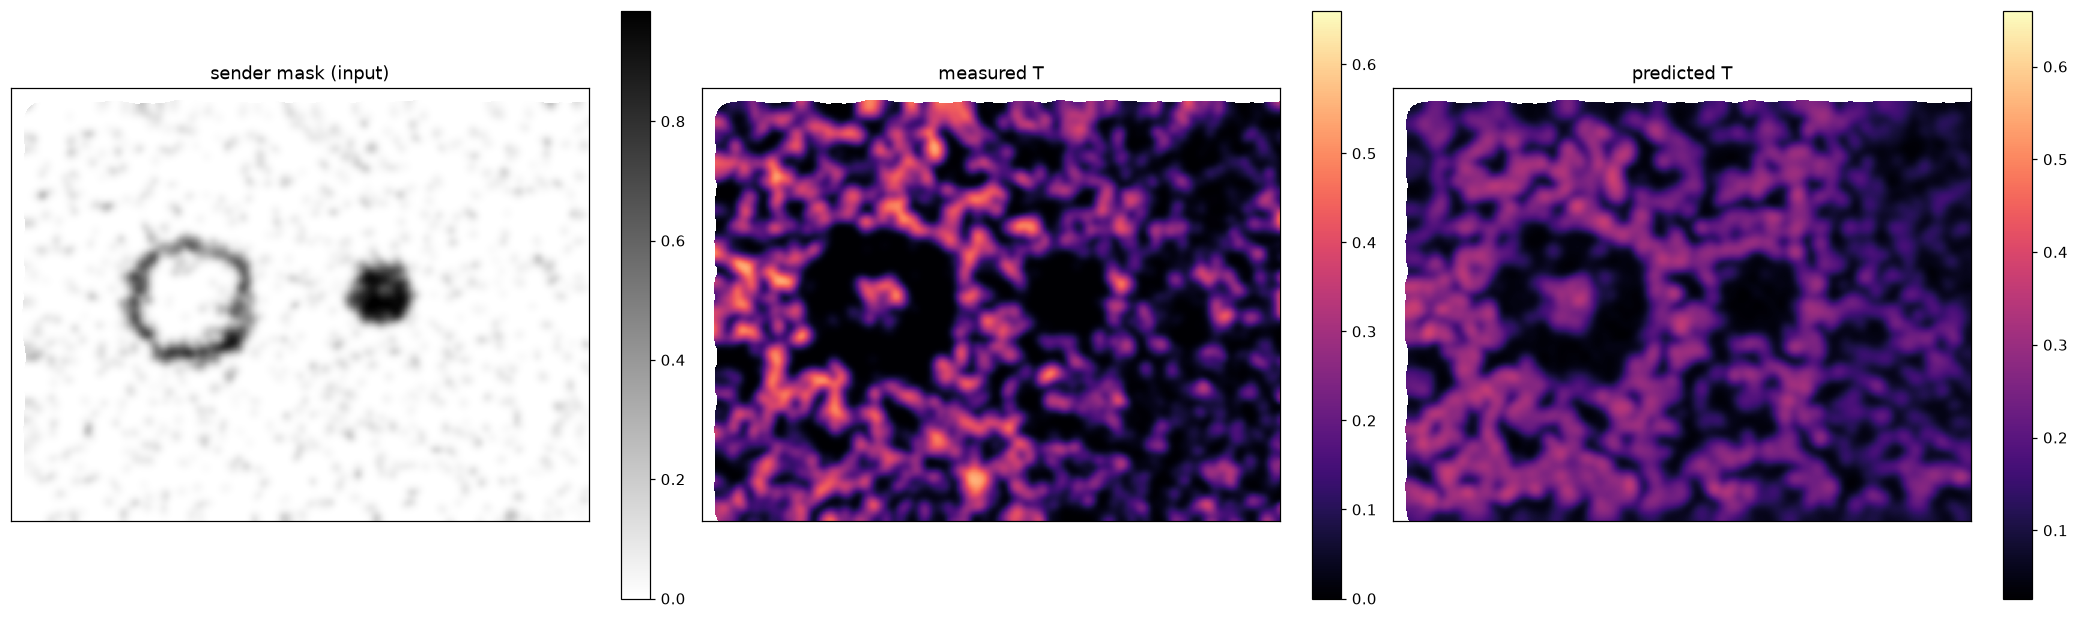

In [12]:
for marker in ['Sox17', 'T']:
    for split_style in ['random', 'blocked']:
        print('=====', marker, split_style, '=====')
        os.makedirs(f'{FIG_DIR}/{marker}_{fname}', exist_ok=True)
        os.makedirs(f'../results/models/{PRIMARY_WELL}', exist_ok=True)

        results = fitted[(marker, split_style)]
        model = results['model']
        model.save_checkpoint(f'../results/models/{PRIMARY_WELL}/{marker}_{fname}.pt')

        ax = pl.plot_training_curves(results['history'], title=f'{marker} ({split_style} split)')
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/{marker}_{fname}/{split_style}_train.png')

        trm, vam, tem = MASKS[split_name]
        tem = tem.numpy()

        fig, ax = plt.subplots(figsize=(3, 3))
        pl.plot_pred_vs_actual(results['y'][tem], results['pred'][tem], results['ypos'][tem], ax=ax,
                                title=f"{marker}: R2={results['metrics']['r2']:.3f}  "
                                        f"AUROC={results['metrics'].get('auroc', float('nan')):.3f}")
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/{marker}_{fname}/{split_style}_r2.png')

        pl.plot_prediction_panel(df, f'BMP4_bin', results['y'], results['pred'], target_name=marker,
                                mask_name=f'sender mask (input)', smooth_sigma=60)
        plt.savefig(f'{FIG_DIR}/{marker}_{fname}/{split_style}_preds.png')
        plt.tight_layout()
        plt.show()